In [1]:
# Verify library versions
import tdt
import neurokit2 as nk
from neurokit2 import signal_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import signal_processing as sp
import importlib

print("TDT version:", tdt.__version__)
print("NeuroKit2 version:", nk.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

TDT version: 0.6.6
NeuroKit2 version: 0.2.10
NumPy version: 1.26.4
Pandas version: 2.2.3
Matplotlib version: 3.10.0


In [2]:
tdt_path = r"E:\resp_test_data\subj11-250227-071832"

mouse = tdt.read_block(tdt_path)

print(mouse)

Found Synapse note file: E:\resp_test_data\subj11-250227-071832\Notes.txt
read from t=0s to t=343.94s
epocs	[struct]
snips	[struct]
streams	[struct]
scalars	[struct]
info	[struct]
time_ranges:	array([[ 0.],
       [inf]])


In [3]:
print(f"streams data: {mouse.streams.keys()}")
print(f"epocs: {mouse.epocs.keys()}")
print(f"info data: {mouse.info.keys()}")
print(f"scalar data: {mouse.scalars.keys()}")
print(f"snips data: {mouse.snips.keys()}")

streams data: dict_keys(['Resp'])
epocs: dict_keys(['Cam1', 'Tick'])
info data: dict_keys(['tankpath', 'blockname', 'start_date', 'utc_start_time', 'stop_date', 'utc_stop_time', 'duration', 'stream_channel', 'snip_channel', 'experiment', 'subject', 'user', 'start', 'stop'])
scalar data: dict_keys([])
snips data: dict_keys([])


In [4]:
# Taking array of 'Resp' Attributes
resp_stream = mouse.streams['Resp']

# Extract key attributes
resp_data = resp_stream.data
fs = resp_stream.fs
start_time = resp_stream.start_time
data_shape = resp_stream.data.shape
size = resp_data.shape[0]
channel = resp_stream.channel
stream_name = resp_stream.name

In [5]:
print(f"Sampling frequency (fs): {fs}")
print(f"Size: {size}")

# Compute total duration in seconds
total_duration = size / fs  

# Convert to minutes
total_duration_minutes = total_duration / 60  

print(f"Total duration of respiratory data: {total_duration} seconds ({total_duration_minutes} minutes)")

Sampling frequency (fs): 305.17578125
Size: 104960
Total duration of respiratory data: 343.932928 seconds (5.732215466666667 minutes)


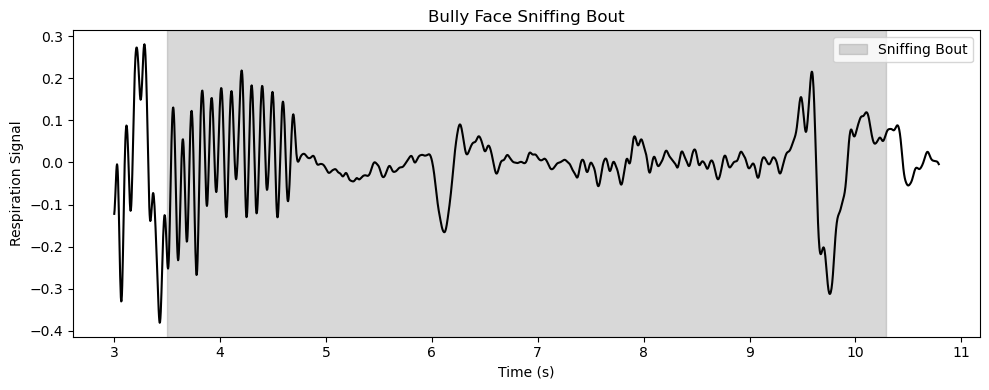

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Define time window
sniff_start = 3.5  # Sniff bout start (seconds)
sniff_end = 10.29  # Sniff bout end (seconds)
window_start = sniff_start - .5  # 2 seconds before
window_end = sniff_end + .5  # 2 seconds after

# Create time array
time_array = np.arange(0, size) / fs + start_time  # Convert indices to time

# Extract indices for the desired time window
start_idx = np.searchsorted(time_array, window_start)
end_idx = np.searchsorted(time_array, window_end)

# Subset the data
plot_time = time_array[start_idx:end_idx]
plot_resp = resp_data[start_idx:end_idx]

# Plot the respiratory signal
plt.figure(figsize=(10, 4))
plt.plot(plot_time, plot_resp, color='black', linewidth=1.5)

# Highlight the sniffing bout (2-7 sec) with a gray background
plt.axvspan(sniff_start, sniff_end, color='gray', alpha=0.3, label="Sniffing Bout")

# Formatting
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal")
plt.title("Bully Face Sniffing Bout")
plt.legend()
plt.grid(False)  # Remove grid if not needed
plt.tight_layout()

# Show plot
plt.show()


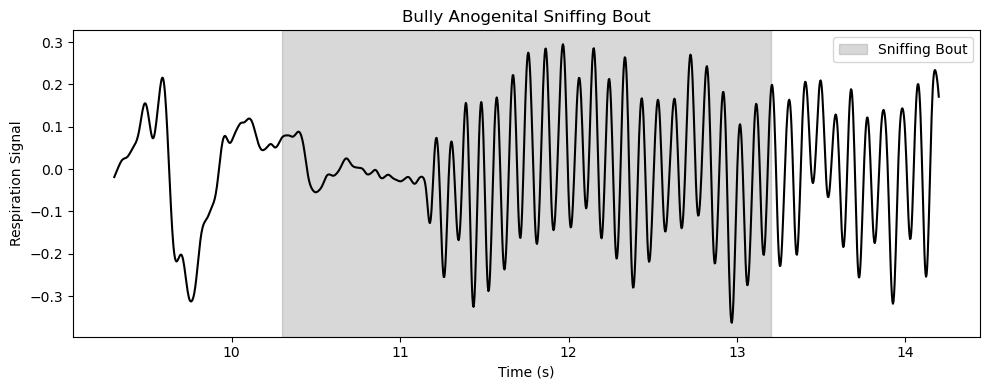

In [16]:
# Define time window
sniff_start = 10.30  # Sniff bout start (seconds)
sniff_end = 13.2  # Sniff bout end (seconds)
window_start = sniff_start - 1  # 2 seconds before
window_end = sniff_end + 1  # 2 seconds after

# Create time array
time_array = np.arange(0, size) / fs + start_time  # Convert indices to time

# Extract indices for the desired time window
start_idx = np.searchsorted(time_array, window_start)
end_idx = np.searchsorted(time_array, window_end)

# Subset the data
plot_time = time_array[start_idx:end_idx]
plot_resp = resp_data[start_idx:end_idx]

# Plot the respiratory signal
plt.figure(figsize=(10, 4))
plt.plot(plot_time, plot_resp, color='black', linewidth=1.5)

# Highlight the sniffing bout (2-7 sec) with a gray background
plt.axvspan(sniff_start, sniff_end, color='gray', alpha=0.3, label="Sniffing Bout")

# Formatting
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal")
plt.title("Bully Anogenital Sniffing Bout")
plt.legend()
plt.grid(False)  # Remove grid if not needed
plt.tight_layout()

# Show plot
plt.show()


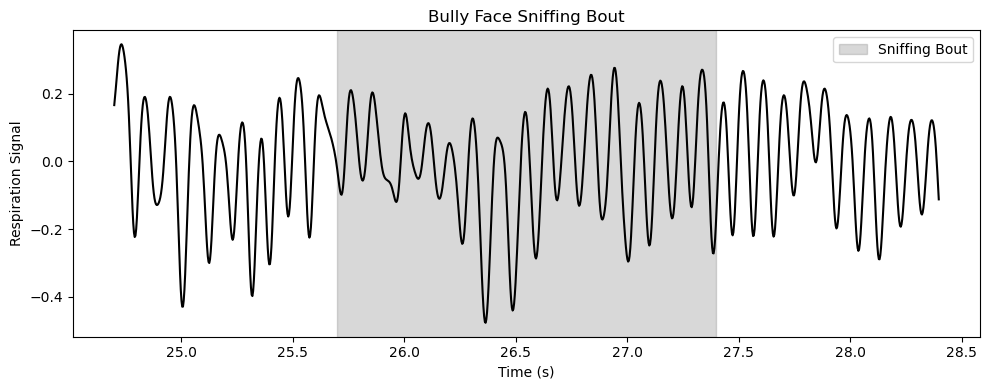

In [15]:
# Define time window
sniff_start = 25.7  # Sniff bout start (seconds)
sniff_end = 27.4  # Sniff bout end (seconds)
window_start = sniff_start - 1  # 2 seconds before
window_end = sniff_end + 1  # 2 seconds after

# Create time array
time_array = np.arange(0, size) / fs + start_time  # Convert indices to time

# Extract indices for the desired time window
start_idx = np.searchsorted(time_array, window_start)
end_idx = np.searchsorted(time_array, window_end)

# Subset the data
plot_time = time_array[start_idx:end_idx]
plot_resp = resp_data[start_idx:end_idx]

# Plot the respiratory signal
plt.figure(figsize=(10, 4))
plt.plot(plot_time, plot_resp, color='black', linewidth=1.5)

# Highlight the sniffing bout (2-7 sec) with a gray background
plt.axvspan(sniff_start, sniff_end, color='gray', alpha=0.3, label="Sniffing Bout")

# Formatting
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal")
plt.title("Bully Face Sniffing Bout")
plt.legend()
plt.grid(False)  # Remove grid if not needed
plt.tight_layout()

# Show plot
plt.show()


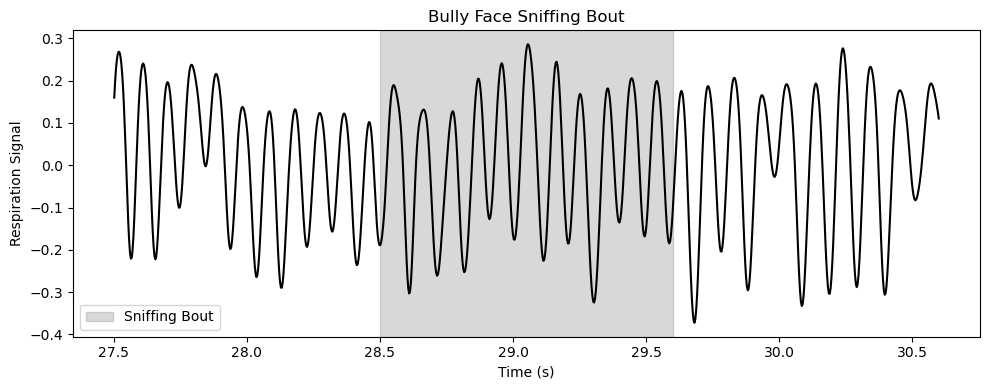

In [18]:
# Define time window
sniff_start = 28.5  # Sniff bout start (seconds)
sniff_end = 29.599  # Sniff bout end (seconds)
window_start = sniff_start - 1  # 2 seconds before
window_end = sniff_end + 1  # 2 seconds after

# Create time array
time_array = np.arange(0, size) / fs + start_time  # Convert indices to time

# Extract indices for the desired time window
start_idx = np.searchsorted(time_array, window_start)
end_idx = np.searchsorted(time_array, window_end)

# Subset the data
plot_time = time_array[start_idx:end_idx]
plot_resp = resp_data[start_idx:end_idx]

# Plot the respiratory signal
plt.figure(figsize=(10, 4))
plt.plot(plot_time, plot_resp, color='black', linewidth=1.5)

# Highlight the sniffing bout (2-7 sec) with a gray background
plt.axvspan(sniff_start, sniff_end, color='gray', alpha=0.3, label="Sniffing Bout")

# Formatting
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal")
plt.title("Bully Face Sniffing Bout")
plt.legend()
plt.grid(False)  # Remove grid if not needed
plt.tight_layout()

# Show plot
plt.show()
